In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import spikeinterface as si
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

import RCP_analysis as rcp
# Adjust if your notebook is not launched from repo root
REPO_ROOT = Path().resolve().parents[0]

PARAMS = rcp.load_experiment_params(
    REPO_ROOT / "config" / "params.yaml",
    repo_root=REPO_ROOT,
)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
ALIGNED_CKPT_ROOT = OUT_BASE / "checkpoints" / "Aligned"

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"
UA_CKPT_OUT = OUT_BASE / "checkpoints" / "UA"

FIG_DIR = OUT_BASE / "figures" / "raw_traces_w_peaks"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR2 = OUT_BASE / "figures" / "raster_counts_gaussian"
FIG_DIR2.mkdir(parents=True, exist_ok=True)

In [2]:
nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
# pick one for now
nprw_pp_folder = nprw_pp_folders[11]
print(nprw_pp_folder)

ua_pp_folders = sorted(UA_CKPT_OUT.glob("pp__*__NS6"))
# pick one for now
ua_pp_folder = ua_pp_folders[11]
print(ua_pp_folder)

aligned_files = sorted(ALIGNED_CKPT_ROOT.glob("aligned__*.npz"))
aligned_npz_path = aligned_files[10]
print(aligned_npz_path)


/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260116_NRR_RW012/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW012_260116_145123
/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260116_NRR_RW012/results/checkpoints/UA/pp__NRR_RW012_012__NS6
/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260116_NRR_RW012/results/checkpoints/Aligned/aligned__NRR_RW012_260116_145123__Intan_012__BR_012.npz


In [13]:
ALIGNED_CKPT_ROOT

PosixPath('/media/bryan/Expansion/Nike/20260116_NRR_RW012/results/checkpoints/Aligned')

In [3]:
rec_nprw = si.load(nprw_pp_folder)
rec_ua = si.load(ua_pp_folder)

fs_nprw = float(rec_nprw.get_sampling_frequency())
fs_ua = float(rec_ua.get_sampling_frequency())

print(rec_nprw)
print(f"Sampling rate: {fs_nprw:.1f} Hz")
print(f"Num channels: {rec_nprw.get_num_channels()}")
print(f"Duration: {rec_nprw.get_num_frames() / fs_nprw:.1f} s")

print(rec_ua)
print(f"Sampling rate: {fs_ua:.1f} Hz")
print(f"Num channels: {rec_ua.get_num_channels()}")
print(f"Duration: {rec_ua.get_num_frames() / fs_ua:.1f} s")

BinaryFolderRecording: 128 channels - 30.0kHz - 1 segments - 6,723,328 samples 
                       224.11s (3.74 minutes) - int16 dtype - 1.60 GiB
Sampling rate: 30000.0 Hz
Num channels: 128
Duration: 224.1 s
BinaryFolderRecording: 128 channels - 30.0kHz - 1 segments - 6,636,586 samples 
                       221.22s (3.69 minutes) - int16 dtype - 1.58 GiB
Sampling rate: 30000.0 Hz
Num channels: 128
Duration: 221.2 s


In [9]:
aligned_npz = np.load(aligned_npz_path, allow_pickle=True)
nprw_peak_ms   = aligned_npz["nprw_peak_ms"].reshape(-1)[0]
nprw_peak_amps   = aligned_npz["nprw_peak_amps"].reshape(-1)[0]

ua_peak_ms   = aligned_npz["ua_peak_ms"].reshape(-1)[0]
ua_peak_amps   = aligned_npz["ua_peak_amps"].reshape(-1)[0]
ua_region = aligned_npz["ua_region"]
ua_region_names = aligned_npz["ua_region_names"]
ua_meta = aligned_npz["ua_meta"].item()
br_idx = int(ua_meta['session'].split('_')[-1])

print("Keys:", aligned_npz.files)
print("UA peak channels:", len(ua_peak_ms), "NPRW peak channels:", len(nprw_peak_ms))
print("Example UA entry:", next(iter(ua_peak_ms.items())) if len(ua_peak_ms) else None)


METADATA_ROOT = SESSION_LOC / "Metadata"; METADATA_ROOT.mkdir(parents=True, exist_ok=True)
SHIFTS_CSV    = METADATA_ROOT / "br_to_intan_shifts.csv"
br2shift_ms = rcp.get_metadata_mapping(SHIFTS_CSV, 'br_idx', 'shift_ms')
shift_ms = br2shift_ms.get(br_idx, None)

shift_ms


Keys: ['nprw_meta', 'nprw_peak_ms', 'nprw_peak_amps', 'ua_meta', 'ua_peak_ms', 'ua_peak_amps', 'ua_elec', 'ua_region', 'ua_region_names', 'ua_port', 'ua_nsp', 'ua_idx_rows', 'hr_sig', 'vog_sig', 'stim_ms', 'shift_ms', 'align_meta', 'beh_ns5_sample', 'beh_cam0', 'beh_cam1', 'beh_cam0_cols', 'beh_cam1_cols', 'beh_t_ms', 'ts_state_num', 'ts_state_char']
UA peak channels: 128 NPRW peak channels: 128
Example UA entry: (np.int64(0), array([0.00000000e+00, 1.33333333e-01, 7.30000000e+00, ...,
       2.21175333e+05, 2.21195600e+05, 2.21215033e+05], shape=(17270,)))


'1595.1333333333332'

In [8]:
br_idx

12

In [34]:
peristim_npz = np.load('/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_141346__BR_005_target_A.npz', allow_pickle=True)
peristim_npz.files

['sess',
 'br_idx',
 'overall_title',
 'meta',
 'ua_meta',
 'nprw_meta',
 'meta_json',
 'ua_meta_json',
 'nprw_meta_json',
 'align_meta_raw',
 'mask_ua',
 'mask_nprw',
 'labels_ua',
 'labels_nprw',
 'n_beh',
 'beh_rel_t',
 'beh_cam0_pos_med',
 'beh_cam1_pos_med',
 'beh_cam0_vel_med',
 'beh_cam1_vel_med',
 'beh_cam0_segs',
 'beh_cam1_segs',
 'beh_cam0_vel_segs',
 'beh_cam1_vel_segs',
 'beh_cam0_names',
 'beh_cam1_names',
 'hr_sig',
 'vog_sig',
 'ts_state_rel_t',
 'ts_state_segs',
 'ts_state_char_segs',
 'ts_state_char',
 'ts_state_num',
 'n_ts_state_trials',
 'stim_ms_ua',
 'stim_ms_nprw',
 'stim_ms',
 'trial_labels_all',
 'NPRW_med',
 'NPRW_var',
 'NPRW_med_counts',
 'NPRW_rates_zeroed',
 'NPRW_counts',
 'NPRW_edges_ms',
 'NPRW_rel_t',
 'NPRW_peak_ms_dedup',
 'NPRW_amps_ms_dedup',
 'n_nprw',
 'UA_med',
 'UA_med_counts',
 'UA_var',
 'UA_rates_zeroed',
 'UA_counts',
 'UA_edges_ms',
 'UA_peak_ms_dedup',
 'UA_amps_ms_dedup',
 'UA_rel_t',
 'n_ua',
 'ua_ids_1based',
 'ua_region',
 'ua_region

/tmp/ipykernel_737753/2717155263.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_counts = cm.get_cmap("jet").copy()
/tmp/ipykernel_737753/2717155263.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_rates  = cm.get_cmap("jet").copy()


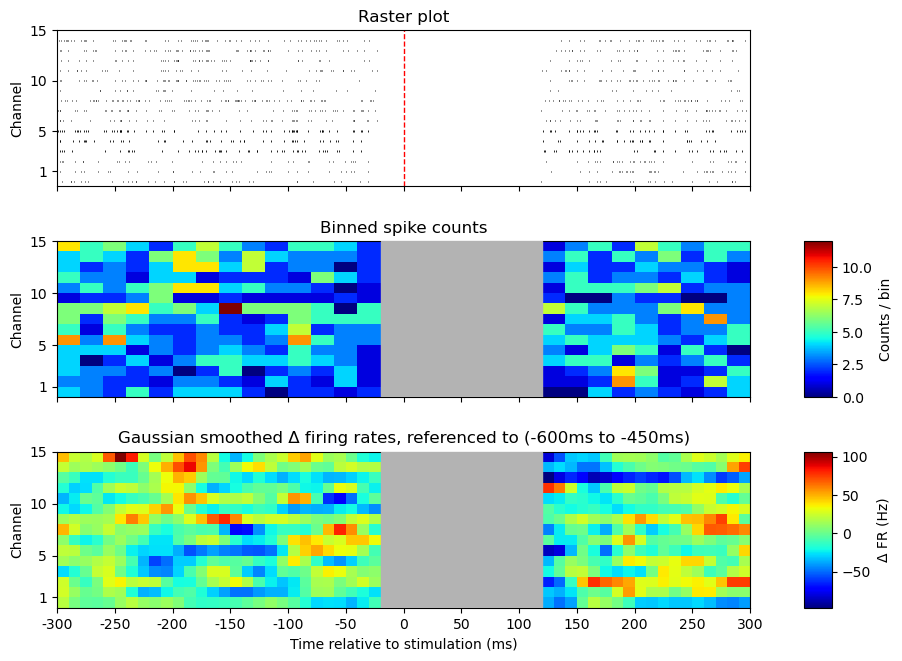

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline

peristim_npz = np.load(
    "/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/PeriStim/Target_A/peristim__NRR_RW011_251203_141346__BR_005_target_A.npz",
    allow_pickle=True
)

# -----------------------
# USER SETTINGS
# -----------------------
SRC          = "NPRW"     # "NPRW" or "UA"
CH0          = 31        # first real channel (inclusive)
N_CH_PLOT    = 15        # will plot CH0..CH0+N_CH_PLOT-1  => 31..45
WIN_HALF_MS  = 300.0
BIN_MS       = 20.0
LINE_LEN     = 0.12
TICK_STEP_MS = 50.0
SHADE_MS     = (-20.0, 20.0)


# -----------------------
# Pick SECOND center only
# -----------------------
stim_ms = np.asarray(peristim_npz.get("stim_ms", []), float).reshape(-1)
if stim_ms.size >= 2:
    CENTER_MS = float(stim_ms[1])
elif stim_ms.size == 1:
    CENTER_MS = float(stim_ms[0])
else:
    CENTER_MS = 0.0

# -----------------------
# Peaks dict (ABS ms) from NPZ
# -----------------------
peak_key = f"{SRC}_peak_ms_dedup"
pk_obj = peristim_npz[peak_key]
peak_ms_dict = pk_obj.reshape(-1)[0] if (isinstance(pk_obj, np.ndarray) and pk_obj.dtype == object) else pk_obj

# -----------------------
# FR from NPZ: (n_trials, n_ch, T) on rel_t axis
# -----------------------
rel_t_ms = peristim_npz[f"{SRC}_rel_t"].astype(float).ravel()          # centers (T,)
rates = peristim_npz[f"{SRC}_rates_zeroed"].astype(float)  # (n_trials, n_ch, T)

ch_sl = slice(CH0, CH0 + N_CH_PLOT)
fr_mean = np.nanmean(rates[:, ch_sl, :], axis=0)           # (N_CH_PLOT, T)

mask_fr   = (rel_t_ms >= -WIN_HALF_MS) & (rel_t_ms <= WIN_HALF_MS)
rel_t_win = rel_t_ms[mask_fr]
fr_win    = fr_mean[:, mask_fr]

# -----------------------
# Counts: histogram spikes REL to CENTER_MS on BIN_MS edges
# -----------------------
edges_counts = np.arange(-WIN_HALF_MS, WIN_HALF_MS + BIN_MS, BIN_MS, dtype=float)
n_bins = len(edges_counts) - 1

spikes_per_ch_rel = []
counts = np.zeros((N_CH_PLOT, n_bins), dtype=np.int32)

for i, ch in enumerate(range(CH0, CH0 + N_CH_PLOT)):       # ch = 31..45
    pk_abs = np.asarray(peak_ms_dict.get(int(ch), []), float).ravel()
    pk_rel = pk_abs - CENTER_MS
    pk_rel = pk_rel[(pk_rel >= -WIN_HALF_MS) & (pk_rel <= WIN_HALF_MS)]
    spikes_per_ch_rel.append(pk_rel)
    counts[i], _ = np.histogram(pk_rel, bins=edges_counts)  # i = 0..14

# -----------------------
# Insert a blank bin at 0 ms (counts + matching edge)
# -----------------------
zero_bin = np.searchsorted(edges_counts, 0.0, side="right") - 1
zero_bin = int(np.clip(zero_bin, 0, counts.shape[1]))

counts_pad = np.concatenate(
    [counts[:, :zero_bin], np.zeros((counts.shape[0], 1), dtype=counts.dtype), counts[:, zero_bin:]],
    axis=1
)
edges_pad = np.insert(edges_counts, zero_bin + 1, edges_counts[zero_bin])

# FR edges from centers (for pcolormesh)
if rel_t_win.size >= 2:
    dt = float(np.nanmedian(np.diff(rel_t_win)))
else:
    dt = float(BIN_MS)
fr_edges = np.r_[rel_t_win[0] - 0.5*dt, rel_t_win + 0.5*dt]

j0 = int(np.searchsorted(rel_t_win, 0.0, side="left"))
j0 = int(np.clip(j0, 0, fr_win.shape[1]))

fr_pad = np.concatenate(
    [fr_win[:, :j0], np.zeros((fr_win.shape[0], 1), dtype=fr_win.dtype), fr_win[:, j0:]],
    axis=1
)
fr_edges_pad = np.insert(fr_edges, j0 + 1, fr_edges[j0])

# -----------------------
# Plot with a dedicated colorbar column (keeps x-axes perfectly aligned)
# -----------------------
cmap_counts = cm.get_cmap("jet").copy()
cmap_rates  = cm.get_cmap("jet").copy()
cmap_rates.set_bad(color="gray")

y_edges = np.arange(N_CH_PLOT + 1)


fig = plt.figure(figsize=(10, 7.5))
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    width_ratios=[1.0, 0.04],      # last col reserved for colorbars
    height_ratios=[1, 1, 1],
    hspace=0.35, wspace=0.15
)

ax_r = fig.add_subplot(gs[0, 0])
ax_c = fig.add_subplot(gs[1, 0], sharex=ax_r)
ax_f = fig.add_subplot(gs[2, 0], sharex=ax_r)

cax_c = fig.add_subplot(gs[1, 1])
cax_f = fig.add_subplot(gs[2, 1])

# Raster
ax_r.eventplot(
    spikes_per_ch_rel,
    lineoffsets=np.arange(N_CH_PLOT),
    linelengths=LINE_LEN,
    colors="black",
    linewidths=0.6,
)
ax_r.axvline(0.0, color="red", ls="--", lw=1)

ax_r.set_ylim(-0.5, N_CH_PLOT - 0.5)
ax_r.set_yticks([1, 5, 10, 15])
ax_r.set_ylabel("Channel")
ax_r.set_title(f"Raster plot")
ax_r.tick_params(axis="x", labelbottom=False)

# Counts
imc = ax_c.pcolormesh(
    edges_pad, y_edges, counts_pad,
    shading="auto", cmap=cmap_counts,
    rasterized=True, antialiased=False
)
imc.set_edgecolor("none")
ax_c.axvline(0.0, color="red", ls="--", lw=1)
ax_c.set_yticks([1, 5, 10, 15])
ax_c.set_ylabel("Channel")
ax_c.set_title(f"Binned spike counts")
ax_c.tick_params(axis="x", labelbottom=False)
ax_c.axvspan(-20, 120, color="0.7", alpha=1, zorder=10)

# FR mean
imf = ax_f.pcolormesh(
    fr_edges_pad, y_edges, fr_pad,
    shading="auto", cmap=cmap_rates,
    rasterized=True, antialiased=False
)
imf.set_edgecolor("none")
ax_f.axvline(0.0, color="red", ls="--", lw=1)
ax_f.set_yticks([1, 5, 10, 15])
ax_f.set_ylabel("Channel")
ax_f.set_xlabel("Time relative to stimulation (ms)")
ax_f.set_title(f"Gaussian smoothed Δ firing rates, referenced to (-600ms to -450ms)")
ax_f.axvspan(-20, 120, color="0.7", alpha=1, zorder=10)

# Force identical x-lims everywhere
for ax in (ax_r, ax_c, ax_f):
    ax.set_xlim(-WIN_HALF_MS, WIN_HALF_MS)

# Ticks
start_rel = np.ceil((-WIN_HALF_MS) / TICK_STEP_MS) * TICK_STEP_MS
end_rel   = np.floor(( WIN_HALF_MS) / TICK_STEP_MS) * TICK_STEP_MS
xt = np.arange(start_rel, end_rel + 0.5*TICK_STEP_MS, TICK_STEP_MS)
ax_f.set_xticks(xt)
ax_f.set_xticklabels([f"{x:.0f}" for x in xt])

# Colorbars in fixed column
cb1 = fig.colorbar(imc, cax=cax_c)
cb1.set_label("Counts / bin")
cb2 = fig.colorbar(imf, cax=cax_f)
cb2.set_label("Δ FR (Hz)")

out_path = FIG_DIR2 / "raster_counts_gaussian.svg"

fig = plt.gcf()          # or: use the `fig` you created earlier
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()


In [23]:
aligned_npz.files
ua_peak_ms

{np.int64(0): array([1.21666667e+01, 3.85666667e+01, 4.83333333e+01, ...,
        6.12197000e+04, 6.12292333e+04, 6.12304333e+04], shape=(5704,)),
 np.int64(1): array([4.73333333e+00, 1.21666667e+01, 1.23000000e+01, ...,
        6.12079667e+04, 6.12088000e+04, 6.12202333e+04], shape=(7595,)),
 np.int64(2): array([5.70000000e+00, 8.70000000e+00, 1.99666667e+01, ...,
        6.11956000e+04, 6.12088000e+04, 6.12184000e+04], shape=(10165,)),
 np.int64(3): array([6.16666667e+00, 7.63333333e+00, 3.06666667e+01, ...,
        6.11552333e+04, 6.11865333e+04, 6.11931667e+04], shape=(5128,)),
 np.int64(4): array([2.12666667e+01, 5.28666667e+01, 6.12666667e+01, ...,
        6.12372333e+04, 6.12378667e+04, 6.12386333e+04], shape=(8451,)),
 np.int64(5): array([1.62000000e+01, 1.67333333e+01, 4.77666667e+01, ...,
        6.12038000e+04, 6.12303333e+04, 6.12368000e+04], shape=(6192,)),
 np.int64(6): array([4.96000000e+01, 6.94000000e+01, 7.49666667e+01, ...,
        6.12333333e+04, 6.12348333e+04, 6.1

In [8]:
rec_nprw

BinaryFolderRecording: 128 channels - 30.0kHz - 1 segments - 3,653,376 samples 
                       121.78s (2.03 minutes) - int16 dtype - 891.94 MiB

In [10]:
nprw_noise_levels = si.get_noise_levels(rec_nprw, method="mad", return_in_uV=False) # They didn't write return_in_uV = False in their documentation

nprw_peak_ms = detect_peaks(
    rec_nprw,
    method="by_channel_torch",
    detect_threshold=3.5,
    peak_sign='both',
    noise_levels=nprw_noise_levels,
    n_jobs=2,
)
def _parse_SI_peaks(peaks) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times = {}
    peak_amp = {}
    for i in np.unique(peaks['channel_index']):
        peak_ch_times = peaks['sample_index'][peaks['channel_index'] == i]
        peak_ch_amp = peaks['amplitude'][peaks['channel_index'] == i]
        peak_times[i] = peak_ch_times
        peak_amp[i] = peak_ch_amp
    return peak_times, peak_amp

nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peak_ms)
nprw_peak_ms = {ch: samps / fs_nprw * 1000.0 for ch, samps in nprw_peak_samps.items()}



ua_noise_levels = si.get_noise_levels(rec_ua, method="mad", return_in_uV=False) # They didn't write return_in_uV in their documentation
        
ua_peak_ms = detect_peaks(
    rec_ua,
    method="by_channel_torch",
    detect_threshold=6,
    peak_sign='both',
    noise_levels=ua_noise_levels,
    n_jobs=2,
)
def _parse_SI_peaks(peaks) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times = {}
    peak_amp = {}
    for i in np.unique(peaks['channel_index']):
        peak_ch_times = peaks['sample_index'][peaks['channel_index'] == i]
        peak_ch_amp = peaks['amplitude'][peaks['channel_index'] == i]
        peak_times[i] = peak_ch_times
        peak_amp[i] = peak_ch_amp
    return peak_times, peak_amp

ua_peak_samps, ua_peak_amps = _parse_SI_peaks(ua_peak_ms)
ua_peak_ms = {ch: samps / fs_ua * 1000.0 for ch, samps in ua_peak_samps.items()}



noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks using by_channel_torch (workers: 2 processes):   0%|          | 0/225 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks using by_channel_torch (workers: 2 processes):   0%|          | 0/222 [00:00<?, ?it/s]

In [10]:
stim_ms = peristim_npz['stim_ms']
stim_ms[0]
shift_ms

'2361.7666666666664'

[saved] /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20260116_NRR_RW012/results/figures/raw_traces_w_peaks/raw_traces_w_peaks_CH10_BR012_100-120ms.svg


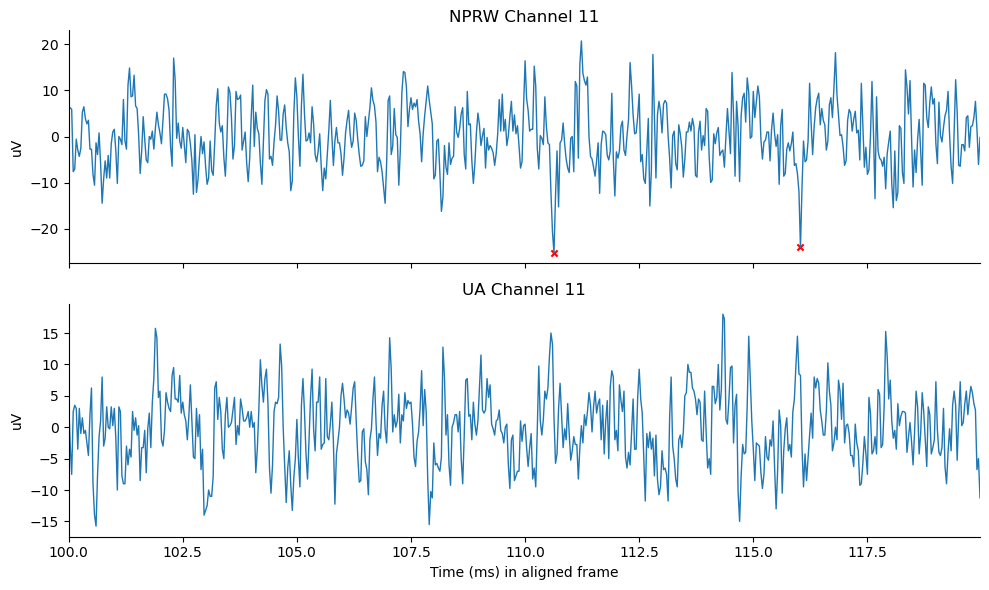

In [11]:
%matplotlib inline
CH = 10
T0_MS, T1_MS = 100, 120
shift_ms = float(shift_ms)

def plot_one(ax, rec, fs, peak_ms_dict, title_prefix,
             window_offset_ms=0.0,
             t_shift_ms=0.0,
             peak_shift_samples=0,
             peak_amp_dict=None):
    dt_ms = 1000.0 / fs
    peak_shift_ms = float(peak_shift_samples) * dt_ms

    w0 = T0_MS + window_offset_ms
    w1 = T1_MS + window_offset_ms

    i0 = int(round(w0 * 1e-3 * fs))
    i1 = int(round(w1 * 1e-3 * fs))
    i0 = max(0, i0)
    i1 = min(rec.get_num_frames(), i1)
    if i1 <= i0:
        ax.set_title(f"{title_prefix}: empty window (check shift/window)")
        ax.axis("off")
        return

    ch_id = rec.get_channel_ids()[CH]
    raw_trace = rec.get_traces(start_frame=i0, end_frame=i1, channel_ids=[ch_id], return_in_uV=True).squeeze()

    # x-axis (aligned frame)
    t = (np.arange(i0, i1) / fs) * 1000.0
    t = t + t_shift_ms

    # peak times (aligned frame)
    pk_t = np.asarray(peak_ms_dict.get(np.int64(CH), []), float) + peak_shift_ms
    m = (pk_t >= t[0]) & (pk_t <= t[-1])
    pk_tw = pk_t[m]

    if pk_tw.size:
        # prefer provided peak amplitudes, if available and same length
        pk_yw = None
        if peak_amp_dict is not None:
            pk_y = np.asarray(peak_amp_dict.get(np.int64(CH), []), float)
            if pk_y.shape == pk_t.shape:
                pk_yw = pk_y[m]

        # fallback: sample from the trace at the peak times
        if pk_yw is None:
            idx = np.searchsorted(t, pk_tw)
            idx = np.clip(idx, 0, raw_trace.size - 1)
            pk_yw = raw_trace[idx]

        ax.scatter(pk_tw, pk_yw, s=20, marker="x", color="red", label="peaks")

    ax.plot(t, raw_trace, lw=1)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylabel("uV")
    ax.set_title(f"{title_prefix} Channel {CH+1}")
    ax.spines[["right", "top"]].set_visible(False)
    return raw_trace


fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# NPRW peaks already aligned; shift trace window + axis, and shift peaks by 2 samples
raw_trace = plot_one(
    axes[0], rec_nprw, fs_nprw, nprw_peak_ms, "NPRW",
    window_offset_ms=0, #+shift_ms, #0,
    t_shift_ms=0, #-shift_ms, #0,
    peak_shift_samples = 3
)

# UA: no timebase shift; shift peaks by 3 samples
plot_one(
    axes[1], rec_ua, fs_ua, ua_peak_ms, "UA",
    window_offset_ms=0.0,
    t_shift_ms=0.0,
    peak_shift_samples = 3
)

axes[1].set_xlabel("Time (ms) in aligned frame")
# axes[0].legend(loc="upper right", frameon=False)

plt.tight_layout()

out_path = FIG_DIR / f"raw_traces_w_peaks_CH{CH}_BR{br_idx:03d}_{T0_MS}-{T1_MS}ms.svg"
fig.savefig(out_path, bbox_inches="tight")   # <-- save FIG, not plt
print(f"[saved] {out_path}")

plt.show()

In [12]:
# import zipfile
# from pathlib import Path

# p = aligned_npz_path
# with zipfile.ZipFile(p, "r") as z:
#     info = sorted(z.infolist(), key=lambda x: x.file_size, reverse=True)
#     for i in info[:30]:
#         comp = i.compress_size / 1e6
#         uncomp = i.file_size / 1e6
#         ratio = (i.compress_size / i.file_size) if i.file_size else 0
#         print(f"{i.filename:40s}  stored={comp:8.2f}MB  raw={uncomp:8.2f}MB  ratio={ratio:5.2f}")


In [13]:
# noise_levels = si.get_noise_levels(rec_nprw, method="mad", return_in_uV=True) # They didn't write return_in_uV in their documentation

# peaks = np.where(np.abs(raw_trace) >= 3 * noise_levels[125])

# plt.plot(raw_trace)
# plt.scatter(peaks, raw_trace[peaks])

# noise_levels[125]

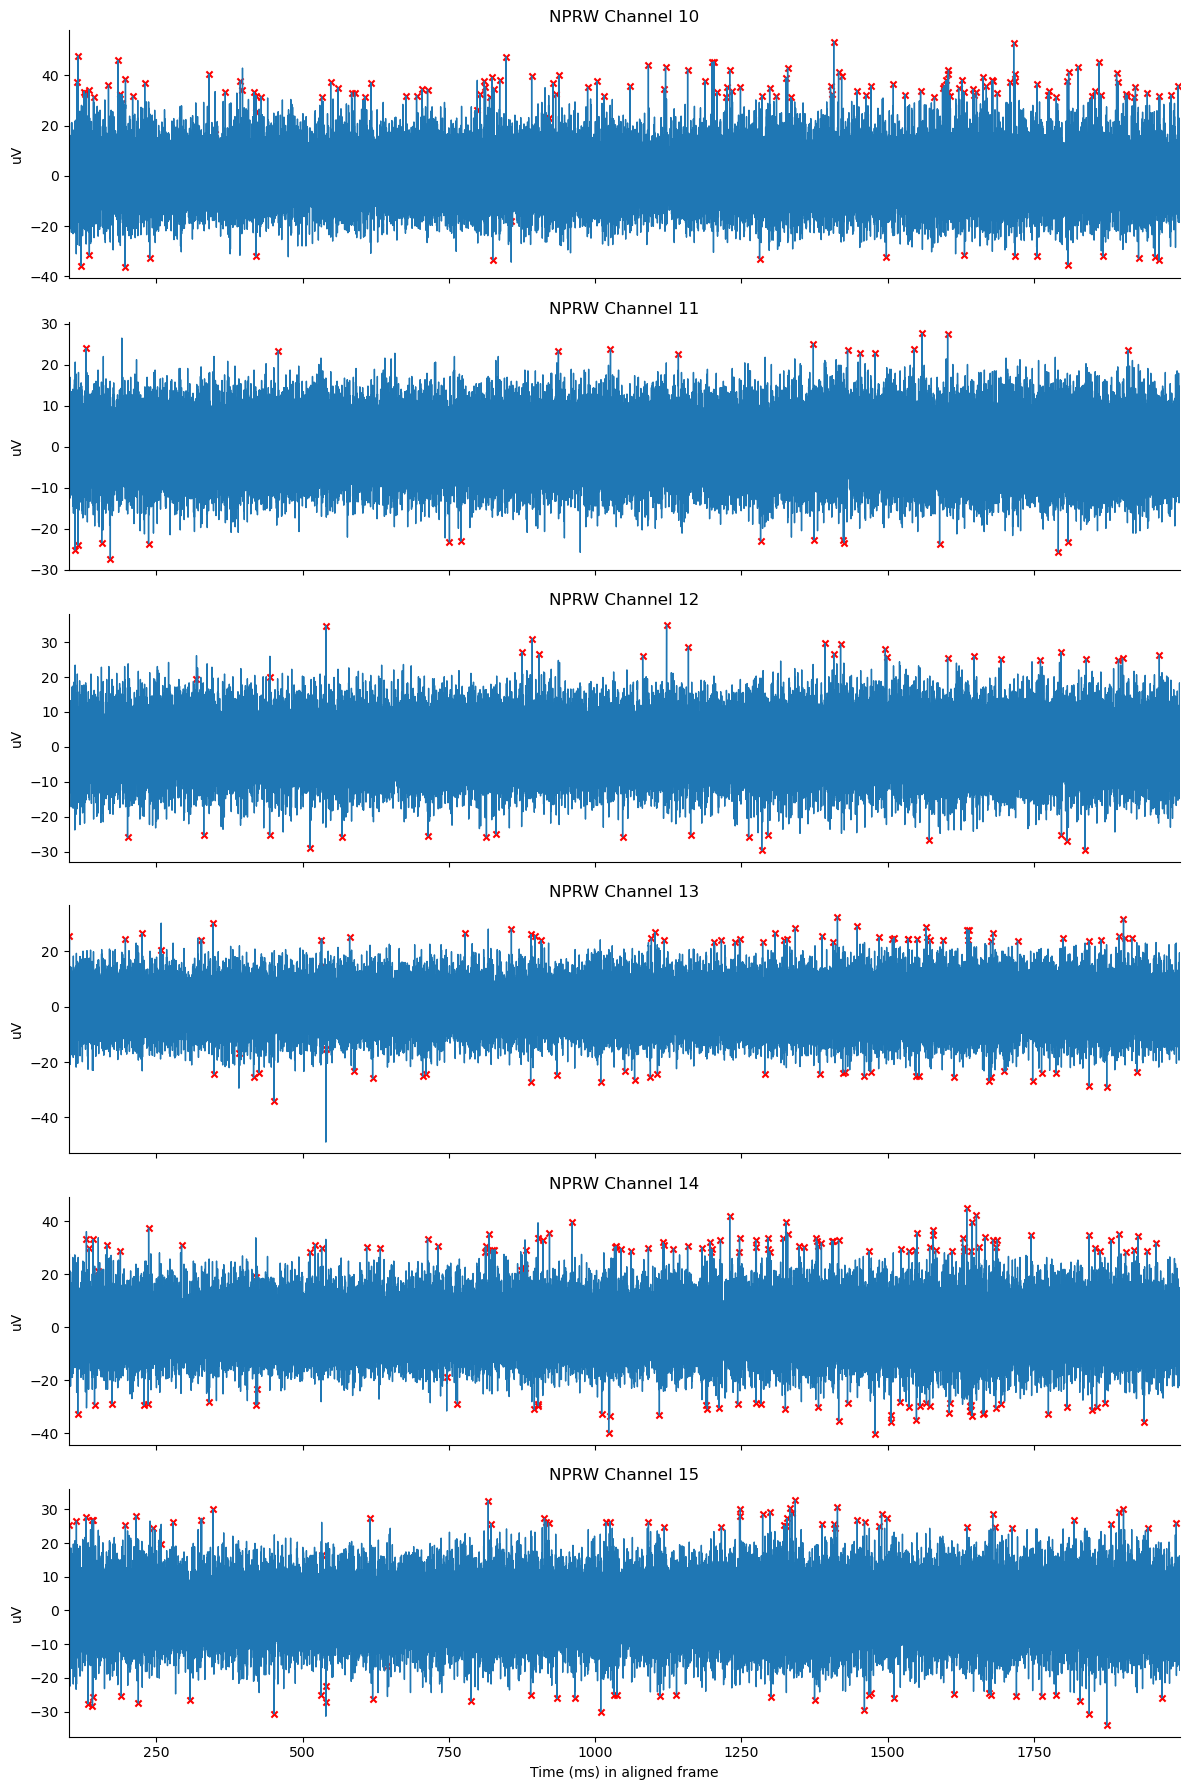

In [13]:
# --- NPRW ONLY: channels 115..128 (1-indexed) ---
CH_START_1IDX, CH_END_1IDX = 10, 15
T0_MS, T1_MS = 100, 2000
ch_idxs = list(range(CH_START_1IDX - 1, CH_END_1IDX))  # 0-indexed: 114..127

ncols = 1
nrows = int(np.ceil(len(ch_idxs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

# noise_levels = si.get_noise_levels(rec_nprw, method="mad", return_in_uV=True) # They didn't write return_in_uV in their documentation
        
# nprw_peak_ms = detect_peaks(
#     rec_nprw,
#     method="by_channel_torch",
#     detect_threshold=4,
#     peak_sign='both',
#     noise_levels=noise_levels,
#     n_jobs=2,
# )
# def _parse_SI_peaks(peaks) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
#     peak_times = {}
#     peak_amp = {}
#     for i in np.unique(peaks['channel_index']):
#         peak_ch_times = peaks['sample_index'][peaks['channel_index'] == i]
#         peak_ch_amp = peaks['amplitude'][peaks['channel_index'] == i]
#         peak_times[i] = peak_ch_times
#         peak_amp[i] = peak_ch_amp
#     return peak_times, peak_amp

# nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peak_ms)
# nprw_peak_ms = {ch: samps / fs_nprw * 1000.0 for ch, samps in nprw_peak_samps.items()}

for ax, ch in zip(axes, ch_idxs):
    CH = ch  # reuse your global CH
    
    plot_one(
        ax, rec_nprw, fs_nprw, nprw_peak_ms, "NPRW",
        window_offset_ms=0,#+shift_ms,
        t_shift_ms=0,#-shift_ms,
        peak_shift_samples=3
    )


# turn off any unused axes
for ax in axes[len(ch_idxs):]:
    ax.axis("off")

axes[min(len(ch_idxs)-1, len(axes)-1)].set_xlabel("Time (ms) in aligned frame")
plt.tight_layout()

# print(f"[saved] {out_path}")
plt.show()


In [15]:
ch_idxs

[114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127]

In [16]:
def _parse_SI_peaks(peaks) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times = {}
    peak_amp = {}
    for i in np.unique(peaks['channel_index']):
        peak_ch_times = peaks['sample_index'][peaks['channel_index'] == i]
        peak_ch_amp = peaks['amplitude'][peaks['channel_index'] == i]
        peak_times[i] = peak_ch_times
        peak_amp[i] = peak_ch_amp
    return peak_times, peak_amp

FILE = '/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/Aligned/aligned__NRR_RW011_251203_135743__Intan_001__BR_002.npz'

temp = np.load(FILE, allow_pickle = True)
ua_peaks = temp['ua_peak_ms']
ua_peak_samps, ua_peak_amps = _parse_SI_peaks(ua_peaks)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
ua_peaks[]

()